# EDA — Favorita Grocery Sales Forecasting

**Mục tiêu notebook:** giúp thành viên mới *hiểu dữ liệu* và *các quyết định feature engineering* trước khi sang phần model.

Bộ Kaggle `favorita-grocery-sales-forecasting` — **multi-file**, daily 2013-01-01 → 2017-08-15, 54 store × ~4100 item (~125M dòng). Project lọc **1 nhóm store** (`store_filter`, mặc định `cluster=[1]`) cho mọi model; dùng chung temporal split (train ≤ 2017-05-15, test 2017-05-16 → 08-15). Metric chính thức: **NWRMSLE** (RMSLE có trọng số 1.25 cho hàng *perishable*).

### Các file & vai trò
| File | Vai trò |
|------|---------|
| `train.csv` | unit_sales theo (date, store, item) + onpromotion |
| `stores.csv` | city, state, type, **cluster** (nhóm store) |
| `items.csv` | family, class, **perishable** (trọng số NWRMSLE) |
| `oil.csv` | giá dầu WTI — proxy kinh tế Ecuador |
| `holidays_events.csv` | lễ/sự kiện theo locale (national/regional/local) |
| `transactions.csv` | số giao dịch/ngày/store — **không dùng** (leakage: chỉ có ở train) |

### 4 insight quan trọng nhất (tóm tắt trước, chứng minh bên dưới)
1. **~40% ngày trong khoảng sống của mỗi chuỗi KHÔNG có dòng** (Favorita bỏ qua ngày bán = 0). → bắt buộc **zero-fill** để lag/rolling tính theo NGÀY, không theo dòng.
2. **94.6% chuỗi (store,item) ra đời sau 2013-01-01** → chỉ zero-fill từ **ngày bán đầu tiên** của từng chuỗi (không từ 2013 toàn cục, tránh bịa "zero giả").
3. `unit_sales` **lệch phải mạnh** + có giá trị 0/âm → **log1p(clip(.,0))** khớp công thức NWRMSLE.
4. Cầu chịu **mùa vụ tuần + năm**, **ngày lương** (15 & cuối tháng), **khuyến mãi**, **lễ** — là nguồn của các feature đã thêm.


In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (11, 4); plt.rcParams['axes.grid'] = True

from src.utils.config import load_config
from src.data.loader import load_cleaned_data, load_raw_data, select_series, _add_series_id
from src.data.features import add_all_features

config = load_config()
print('store_filter:', config['store_filter'])
print('split:', config['split'])

store_filter: {'by': 'cluster', 'value': [1]}
split: {'train_end': '2017-05-15', 'test_start': '2017-05-16', 'test_end': '2017-08-15'}


## 1. Nạp dữ liệu (đã clean + zero-fill)

Ưu tiên file cache `data/cleaned/train_cleaned.feather` (sinh bởi `python scripts/clean_data.py`). Nếu chưa có → dựng trực tiếp từ raw (chậm hơn).

> File cache giữ phần **join + zero-fill** (nặng, không phụ thuộc config). Feature engineering áp dụng sau khi load (rẻ).

In [2]:
from pathlib import Path
cleaned = Path('..') / config['data']['cleaned_dir'] / 'train_cleaned.feather'
if cleaned.exists():
    df = pd.read_feather(cleaned)
    df['date'] = pd.to_datetime(df['date'])
    if 'series_id' not in df.columns:
        df = _add_series_id(df)
    print('Loaded cache:', cleaned)
else:
    print('Cache chưa có → dựng từ raw (vài phút)...')
    df, _ = load_raw_data(config)
df = df.sort_values(['series_id','date']).reset_index(drop=True)
print(f'rows={len(df):,} | series={df.series_id.nunique():,} | '
      f'span {df.date.min().date()} → {df.date.max().date()} | cols={len(df.columns)}')
df.head()

Loaded cache: ../data/cleaned/train_cleaned.feather


rows=12,457,848 | series=10,709 | span 2013-01-01 → 2017-08-15 | cols=20


,store_nbr,item_nbr,date,id,unit_sales,onpromotion,city,state,type,cluster,family,class,perishable,is_imputed,dcoilwtico,holiday_national,holiday_regional,holiday_local,is_holiday,series_id
0,24,96995,2013-01-09,302230.0,2.0,0,Guayaquil,Guayas,D,1.0,GROCERY I,1093.0,0,0,93.080000,0,0,0,0,0
1,24,96995,2013-01-10,NaN,0.0,0,Guayaquil,Guayas,D,1.0,GROCERY I,1093.0,0,1,93.810000,0,0,0,0,0
2,24,96995,2013-01-11,NaN,0.0,0,Guayaquil,Guayas,D,1.0,GROCERY I,1093.0,0,1,93.600000,0,0,0,0,0
3,24,96995,2013-01-12,419989.0,2.0,0,Guayaquil,Guayas,D,1.0,GROCERY I,1093.0,0,0,93.823333,0,0,0,0,0
4,24,96995,2013-01-13,NaN,0.0,0,Guayaquil,Guayas,D,1.0,GROCERY I,1093.0,0,1,94.046667,0,0,0,0,0


## 2. Tổng quan & chất lượng dữ liệu

Kiểm tra null, dải giá trị, số store/item. Sau zero-fill **không còn null** ở target/exog; `is_imputed=1` đánh dấu dòng được điền 0.

In [3]:
print('Null mỗi cột (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))
print('\nunit_sales:', df.unit_sales.describe()[['min','mean','50%','max']].to_dict())
if 'is_imputed' in df.columns:
    r = df.is_imputed.mean()
    print(f'\nTỉ lệ dòng zero-fill (is_imputed=1): {r:.1%}  '
          f'→ ~{r:.0%} ngày trong khoảng sống của chuỗi vốn KHÔNG có dòng trong train.csv')

Null mỗi cột (top 10):


id             4999225
store_nbr            0
item_nbr             0
date                 0
unit_sales           0
onpromotion          0
city                 0
state                0
type                 0
cluster              0
dtype: int64



unit_sales: {'min': 0.0, 'mean': 4.365054055267009, '50%': 1.0, 'max': 6909.0}

Tỉ lệ dòng zero-fill (is_imputed=1): 40.1%  → ~40% ngày trong khoảng sống của chuỗi vốn KHÔNG có dòng trong train.csv


## 3. ⭐ Độ thưa & zero-fill (insight #1, #2)

Favorita **không ghi** ngày bán = 0 → mỗi chuỗi (store,item) bị "thủng" ngày. Nếu để nguyên, `groupby.shift(7)` dịch **7 dòng** chứ không phải **7 ngày** → lag/rolling sai.

Biểu đồ dưới: với vài chuỗi mẫu, so sánh số ngày *quan sát thật* vs *khoảng ngày liên tục* (đã zero-fill).

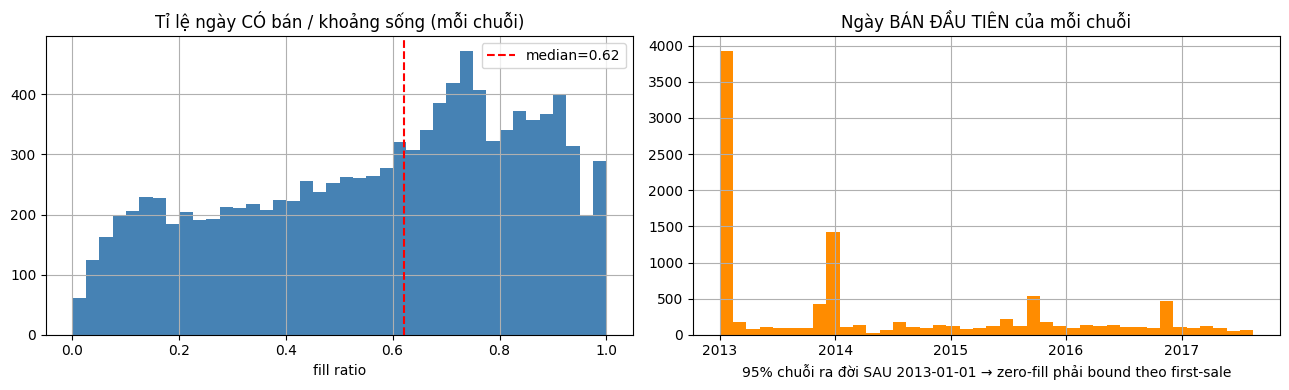

Median fill ratio=0.62 → ~38% ngày là implicit-zero.


In [4]:
# Phân bố tỉ lệ lấp đầy & ngày bắt đầu của từng chuỗi
g = df.groupby('series_id')
span = (g['date'].max() - g['date'].min()).dt.days + 1
if 'is_imputed' in df.columns:
    observed = g['is_imputed'].apply(lambda s: (s == 0).sum())
else:
    observed = g.size()
fill_ratio = (observed / span).clip(0, 1)
first_sale = g['date'].min()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(fill_ratio, bins=40, color='steelblue'); ax[0].set_title('Tỉ lệ ngày CÓ bán / khoảng sống (mỗi chuỗi)')
ax[0].set_xlabel('fill ratio'); ax[0].axvline(fill_ratio.median(), color='r', ls='--', label=f'median={fill_ratio.median():.2f}'); ax[0].legend()
ax[1].hist(first_sale, bins=40, color='darkorange'); ax[1].set_title('Ngày BÁN ĐẦU TIÊN của mỗi chuỗi')
late = (first_sale > df.date.min()).mean()
ax[1].set_xlabel(f'{late:.0%} chuỗi ra đời SAU 2013-01-01 → zero-fill phải bound theo first-sale')
plt.tight_layout(); plt.show()
print(f'Median fill ratio={fill_ratio.median():.2f} → ~{1-fill_ratio.median():.0%} ngày là implicit-zero.')

**Kết luận:** zero-fill thực hiện trong `cleaner.reindex_fill_dates()` — reindex mỗi chuỗi về lưới ngày liên tục **từ ngày bán đầu → cuối**, điền `unit_sales=0`, `onpromotion=0`, ffill thuộc tính tĩnh (store/item), thêm cờ `is_imputed`. Chạy **trước** merge oil/holiday để ngày chèn nhận đúng giá dầu & cờ lễ theo ngày.

## 4. Phân phối target & log1p (insight #3)

`unit_sales` lệch phải mạnh (ít item bán rất nhiều). log1p ổn định phương sai & khớp RMSLE.

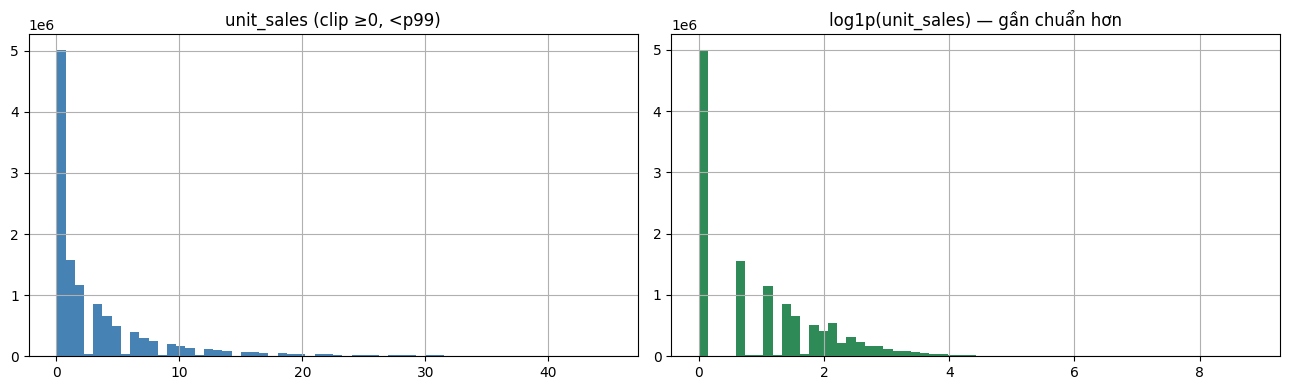

Mean unit_sales theo perishable:
perishable
0    3.644528
1    6.532628
Name: unit_sales, dtype: float64


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
s = df.unit_sales.clip(lower=0)
ax[0].hist(s[s < s.quantile(0.99)], bins=60, color='steelblue'); ax[0].set_title('unit_sales (clip ≥0, <p99)')
ax[1].hist(np.log1p(s), bins=60, color='seagreen'); ax[1].set_title('log1p(unit_sales) — gần chuẩn hơn')
plt.tight_layout(); plt.show()
if 'perishable' in df.columns:
    print('Mean unit_sales theo perishable:'); print(df.groupby('perishable').unit_sales.mean())

## 5. Mùa vụ: tuần & năm (insight #4)

Pattern theo **thứ trong tuần** (cuối tuần cao) và **tháng** (đỉnh cuối năm) → nguồn của Fourier (weekly K=3, yearly K=2) + cyclical sin/cos.

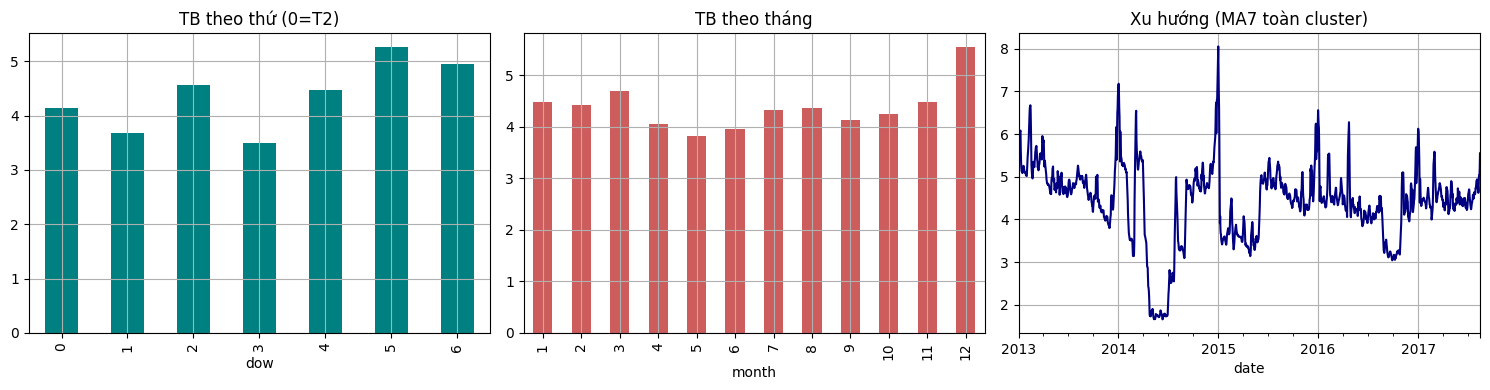

In [6]:
df['dow'] = df.date.dt.dayofweek; df['month'] = df.date.dt.month
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df.groupby('dow').unit_sales.mean().plot(kind='bar', ax=ax[0], color='teal'); ax[0].set_title('TB theo thứ (0=T2)')
df.groupby('month').unit_sales.mean().plot(kind='bar', ax=ax[1], color='indianred'); ax[1].set_title('TB theo tháng')
df.groupby('date').unit_sales.mean().rolling(7).mean().plot(ax=ax[2], color='navy'); ax[2].set_title('Xu hướng (MA7 toàn cluster)')
plt.tight_layout(); plt.show()

## 6. Ngày lương Ecuador — 15 & cuối tháng (insight #4)

Khu vực công trả lương giữa & cuối tháng → cầu tăng hậu lương (đặc biệt cuối tuần). Feature: `is_payday`, `days_since_payday`, `days_to_payday`.

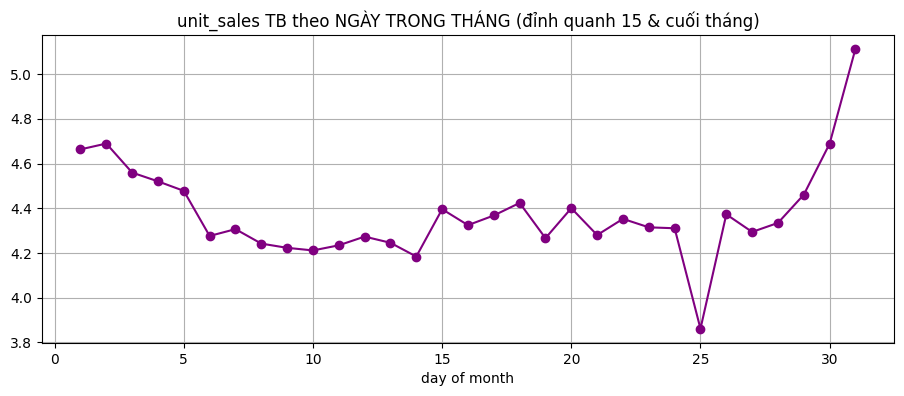

Mean theo is_payday:
is_payday
0    4.350441
1    4.572795
Name: unit_sales, dtype: float64


In [7]:
dom = df.date.dt.day
ld = df.date.dt.days_in_month
df['is_payday'] = ((dom == 15) | (dom == ld)).astype(int)
by_dom = df.groupby(dom).unit_sales.mean()
ax = by_dom.plot(marker='o', color='purple'); ax.set_title('unit_sales TB theo NGÀY TRONG THÁNG (đỉnh quanh 15 & cuối tháng)')
ax.set_xlabel('day of month'); plt.show()
print('Mean theo is_payday:'); print(df.groupby('is_payday').unit_sales.mean())

## 7. Khuyến mãi & lễ (insight #4)

`onpromotion` (biết trước cả ở test → exog hợp lệ) và cờ `is_holiday` đều nâng cầu. Feature promo: `promo_count_7/14/30`, `days_since_last_promo`, `days_until_next_promo`.

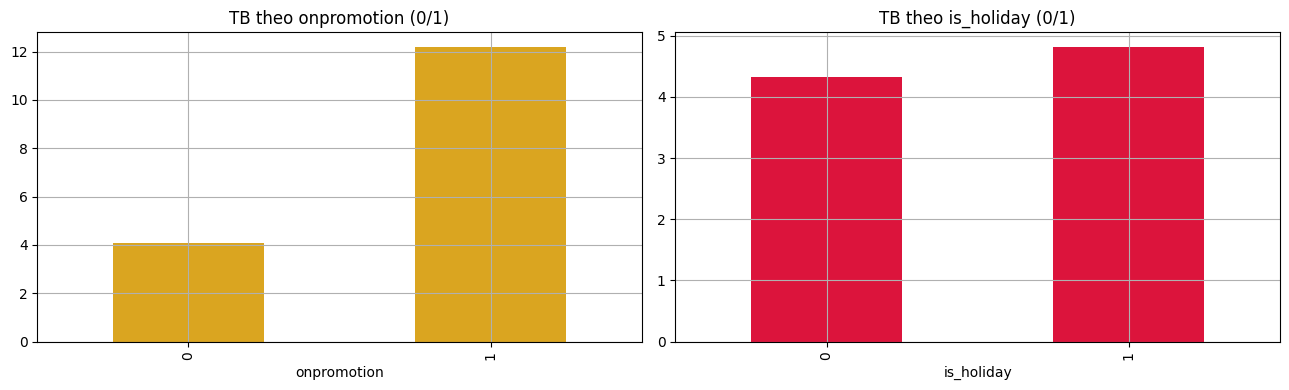

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
if 'onpromotion' in df.columns:
    df.groupby('onpromotion').unit_sales.mean().plot(kind='bar', ax=ax[0], color='goldenrod')
    ax[0].set_title('TB theo onpromotion (0/1)')
if 'is_holiday' in df.columns:
    df.groupby('is_holiday').unit_sales.mean().plot(kind='bar', ax=ax[1], color='crimson')
    ax[1].set_title('TB theo is_holiday (0/1)')
plt.tight_layout(); plt.show()

## 8. Giá dầu (oil) — bối cảnh kinh tế

Ecuador phụ thuộc dầu; `dcoilwtico` nội suy ngày thiếu + `oil_lag_7`. Tương quan với tổng cầu thường **âm nhẹ** (dầu thấp ↔ kinh tế yếu).

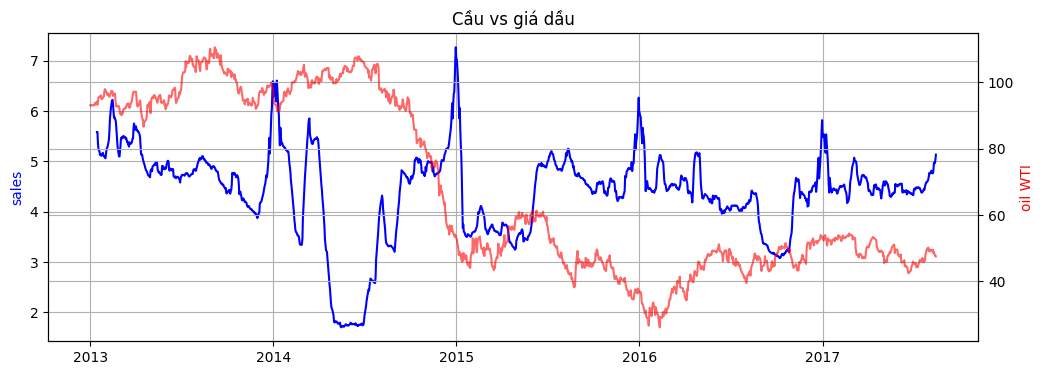

corr(sales, oil) = -0.044


In [9]:
if 'dcoilwtico' in df.columns:
    daily = df.groupby('date').agg(sales=('unit_sales','mean'), oil=('dcoilwtico','first'))
    fig, ax1 = plt.subplots(figsize=(12,4)); ax2 = ax1.twinx()
    ax1.plot(daily.index, daily.sales.rolling(14).mean(), 'b-', label='sales MA14'); ax1.set_ylabel('sales', color='b')
    ax2.plot(daily.index, daily.oil, 'r-', alpha=.6, label='oil'); ax2.set_ylabel('oil WTI', color='r')
    ax1.set_title('Cầu vs giá dầu'); plt.show()
    print('corr(sales, oil) =', round(daily.sales.corr(daily.oil), 3))

## 9. ACF/PACF & tính dừng (cho ARIMA/SARIMAX)

Trên 1 chuỗi đại diện (volume cao). ACF đỉnh tại lag 7 ⇒ mùa vụ tuần; cần sai phân để dừng.

Chuỗi đại diện series_id= 194 | len= 1664
Suggested d = 0


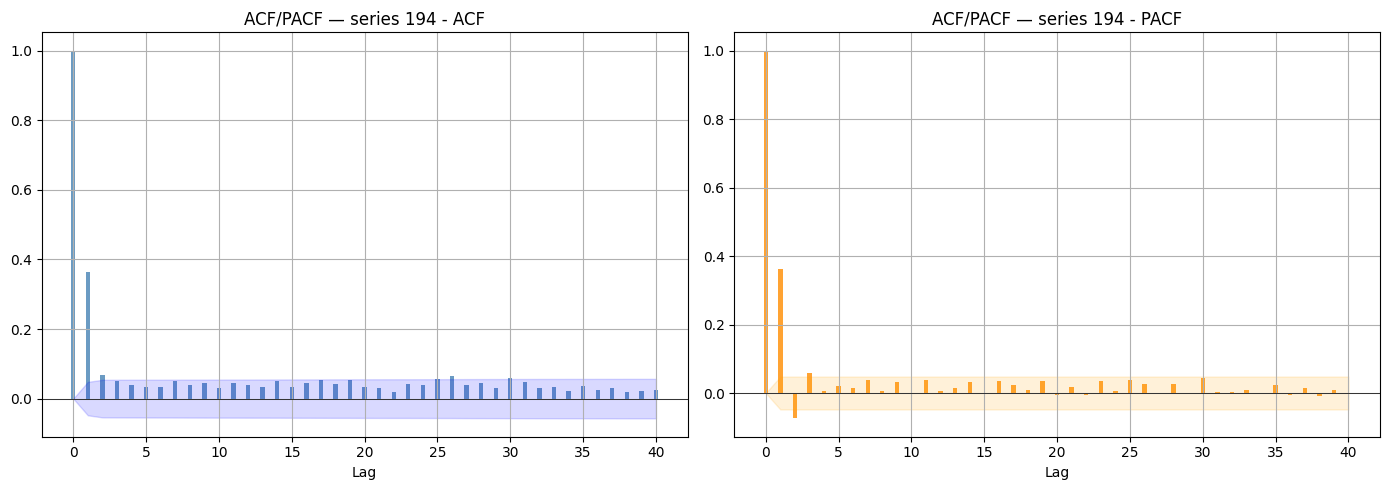

In [10]:
from src.analysis.acf_pacf import plot_acf_pacf
from src.analysis.stationarity import test_stationarity
top = df.groupby('series_id').unit_sales.sum().idxmax()
one = df[df.series_id == top].set_index('date').unit_sales.asfreq('D').fillna(0)
arr = one.to_numpy()
print('Chuỗi đại diện series_id=', top, '| len=', len(arr))
res = test_stationarity(arr)
print('Suggested d =', res.get('suggested_d'))
from IPython.display import display
fig = plot_acf_pacf(arr, nlags=40, title=f'ACF/PACF — series {top}')  # hàm tự close → display(fig)
display(fig)

## 10. Feature engineering — kiểm tra đầu ra (sẵn sàng cho model)

Áp `add_all_features` (+ log transform) trên mẫu chuỗi → liệt kê cột, xác nhận **0 NaN**. Đây là input cuối cùng cho model.

In [11]:
from src.data.features import apply_log_transform
sample_ids = df.series_id.drop_duplicates().sample(min(200, df.series_id.nunique()), random_state=42)
sdf = df[df.series_id.isin(sample_ids)].copy()
feat = add_all_features(sdf, feature_cfg=config.get('features'))
if config.get('use_log_sales'):
    feat = apply_log_transform(feat)
print(f'Sau FE: {feat.shape[0]:,} dòng × {feat.shape[1]} cột | NaN tổng = {int(feat.isnull().sum().sum())}')
groups = {
 'time': ['year','month','weekofyear','dayofmonth','dayofweek','is_weekend','month_sin','month_cos','dow_sin','dow_cos'],
 'fourier': [c for c in feat.columns if c.startswith('fourier_')],
 'lag': [c for c in feat.columns if c.startswith('unit_sales_lag_')],
 'rolling': [c for c in feat.columns if c.startswith('unit_sales_rolling_')],
 'group_mean': ['series_dow_avg','store_avg','item_avg','family_avg'],
 'payday': ['is_payday','days_since_payday','days_to_payday'],
 'zero_sales': ['zero_sales_last_28'],
 'promo': ['onpromotion','promo_rolling_rate','promo_count_7','promo_count_14','promo_count_30','days_since_last_promo','days_until_next_promo'],
 'oil/holiday/perish': ['dcoilwtico','oil_lag_7','is_holiday','holiday_national','holiday_regional','holiday_local','perishable','is_imputed'],
}
for k, cols in groups.items():
    have = [c for c in cols if c in feat.columns]
    print(f'  {k:18s} ({len(have)}): {have}')

Sau FE: 230,103 dòng × 73 cột | NaN tổng = 0
  time               (10): ['year', 'month', 'weekofyear', 'dayofmonth', 'dayofweek', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos']
  fourier            (10): ['fourier_w_sin_1', 'fourier_w_cos_1', 'fourier_w_sin_2', 'fourier_w_cos_2', 'fourier_w_sin_3', 'fourier_w_cos_3', 'fourier_y_sin_1', 'fourier_y_cos_1', 'fourier_y_sin_2', 'fourier_y_cos_2']
  lag                (8): ['unit_sales_lag_1', 'unit_sales_lag_7', 'unit_sales_lag_14', 'unit_sales_lag_28', 'unit_sales_lag_30', 'unit_sales_lag_60', 'unit_sales_lag_90', 'unit_sales_lag_365']
  rolling            (9): ['unit_sales_rolling_mean_7', 'unit_sales_rolling_std_7', 'unit_sales_rolling_median_7', 'unit_sales_rolling_mean_14', 'unit_sales_rolling_std_14', 'unit_sales_rolling_median_14', 'unit_sales_rolling_mean_30', 'unit_sales_rolling_std_30', 'unit_sales_rolling_median_30']
  group_mean         (4): ['series_dow_avg', 'store_avg', 'item_avg', 'family_avg']
  payday      

## 11. Kết luận & bước tiếp theo (model)

**Đã hoàn thành (data layer, sẵn sàng cho model input):**
- ✅ Multi-file join (stores/items/oil/holidays) + clip âm + fill onpromotion.
- ✅ **Zero-fill** mỗi chuỗi về lưới ngày liên tục, bound theo first-sale (`cleaner.reindex_fill_dates`).
- ✅ Feature engineering: time + Fourier + lag(1..365) + rolling + group-mean (store/item/family) + **payday** + **promo-timing** + **zero-sales count** + exog (oil/holiday/perishable).
- ✅ log1p(clip) khớp NWRMSLE; preprocess split theo thời gian + RobustScaler (skip cho ARIMA/SARIMAX/Prophet).
- ✅ Cache `data/cleaned/train_cleaned.feather` → load nhanh.

**Bước tiếp (phần model):**
1. ARIMA/SARIMAX: dùng ACF/PACF (mục 9) chọn (p,d,q)(P,D,Q)₇ thật (hiện placeholder).
2. XGBoost/LSTM (global): tận dụng toàn bộ feature trên; chú ý `series_sample.n_series=null` để dùng hết chuỗi.
3. Validation khớp horizon (NWRMSLE trên cửa sổ cuối train); xem `src/evaluation/cross_validation.py`.
4. So sánh model qua `scripts/compare_cv.py` (sort theo NWRMSLE).

> Tham khảo chi tiết feature so với top Kaggle: `plans/reports/researcher-260530-1038-favorita-eda-fe-delta.md`.